In [ ]:
!pip install shap

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    classification_report,
    silhouette_score,
    adjusted_rand_score
)
from sklearn.tree import DecisionTreeClassifier, export_text


In [ ]:
# ==== CONFIG ====
RANDOM_STATE = 42

# Your CSV path
path = "devx_2024_modellingDataset_FLOtop5_union.csv"
df = pd.read_csv(path)

targets = ["Frustration", "JobSat", "JobPerspectiveClass"]
features = [c for c in df.columns if c not in targets]

# Basic cleaning
df = df.fillna(df.median(numeric_only=True))
for t in targets:
    df[t] = df[t].astype(int)

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_samples = X_scaled.shape[0]
print("Data shape:", df.shape)


Data shape: (65437, 17)


In [ ]:
rf_models = {}
cal_models = {}
probs_dict = {}

for target in targets:
    print("\n==============================")
    print(f"Training calibrated model for: {target}")
    print("==============================\n")

    y = df[target].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Base RF
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # Calibrated wrapper (isotonic; change to 'sigmoid' if too slow)
    cal = CalibratedClassifierCV(
        estimator=rf,
        method="isotonic",
        cv=3
    )
    cal.fit(X_train, y_train)

    # Evaluation on test split
    y_pred = cal.predict(X_test)
    print(classification_report(y_test, y_pred))

    # Store models
    rf_models[target] = rf
    cal_models[target] = cal

    # Per-instance calibrated probabilities on FULL dataset
    probs = cal.predict_proba(X_scaled)   # shape (n_samples, n_classes)
    probs_dict[target] = probs

# Concatenate all target probabilities → one vector per instance
prob_blocks = [probs_dict[t] for t in targets]
probs_all = np.concatenate(prob_blocks, axis=1)   # shape (n_samples, sum(classes))
print("\nprobability vector shape:", probs_all.shape)



Training calibrated model for: Frustration

              precision    recall  f1-score   support

           0       0.83      0.32      0.47      2146
           1       0.76      0.95      0.85      9114
           2       0.51      0.26      0.34      1828

    accuracy                           0.75     13088
   macro avg       0.70      0.51      0.55     13088
weighted avg       0.74      0.75      0.71     13088


Training calibrated model for: JobSat

              precision    recall  f1-score   support

           0       0.40      0.02      0.04       731
           1       0.79      0.86      0.82      8850
           2       0.57      0.56      0.56      3507

    accuracy                           0.73     13088
   macro avg       0.59      0.48      0.47     13088
weighted avg       0.71      0.73      0.71     13088


Training calibrated model for: JobPerspectiveClass



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       305
           1       0.00      0.00      0.00      1126
           2       0.89      1.00      0.94     11657

    accuracy                           0.89     13088
   macro avg       0.30      0.33      0.31     13088
weighted avg       0.79      0.89      0.84     13088


probability vector shape: (65437, 9)


In [ ]:
shap_global = {}
shap_inst = {}

shap_sample_size = min(1000, n_samples)   # up to 1000 rows for SHAP-based clustering
shap_idx = np.random.RandomState(RANDOM_STATE).choice(
    np.arange(n_samples), size=shap_sample_size, replace=False
)
X_shap = X_scaled[shap_idx]

for target in targets:
    print("\n=======================================")
    print(f"Computing SHAP for target: {target}")
    print("=======================================\n")

    rf = rf_models[target]

    explainer = shap.TreeExplainer(
        rf,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )
    shap_values = explainer.shap_values(X_shap)

    # Your RF produces shape (samples, features, classes)
    shap_values = np.array(shap_values)
    print("SHAP raw shape:", shap_values.shape)

    if shap_values.ndim == 3:
        # (samples, features, classes) → collapse classes -> (samples, features)
        shap_abs = np.mean(np.abs(shap_values), axis=2)
    elif shap_values.ndim == 2:
        shap_abs = np.abs(shap_values)
    else:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")

    # Global importance (mean over samples) → length = n_features
    global_imp = shap_abs.mean(axis=0)
    shap_global[target] = global_imp

    # Per-instance SHAP (for clustering) → (shap_sample_size, n_features)
    shap_inst[target] = shap_abs

# Build global SHAP matrix for visualization (optional, like you already did)
shap_matrix = pd.DataFrame(shap_global, index=features)
print("\nGlobal SHAP matrix shape:", shap_matrix.shape)
shap_matrix.head()



Computing SHAP for target: Frustration

SHAP raw shape: (1000, 14, 3)

Computing SHAP for target: JobSat

SHAP raw shape: (1000, 14, 3)

Computing SHAP for target: JobPerspectiveClass

SHAP raw shape: (1000, 14, 3)

Global SHAP matrix shape: (14, 3)


,Frustration,JobSat,JobPerspectiveClass
ai_challenges,0.026456,0.009543,0.011365
ai_tools,0.007489,0.009062,0.062054
coding_count,0.013967,0.020731,0.004177
coding_years,0.011446,0.026174,0.012062
comm_tools_used,0.011853,0.010291,0.007915


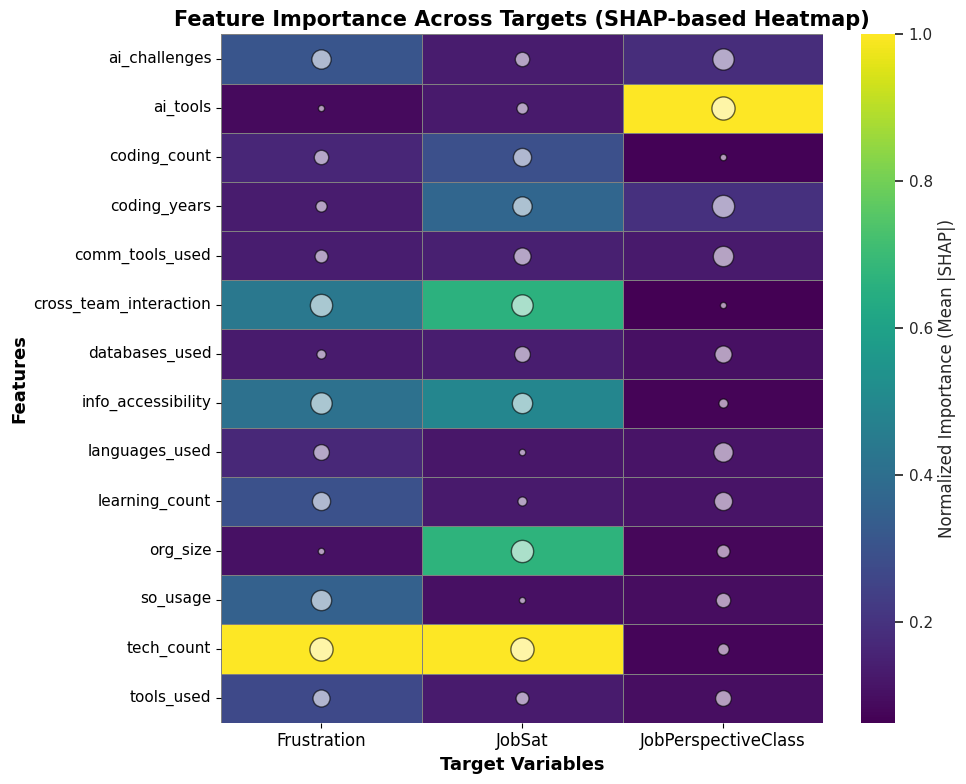

In [ ]:
# Normalize each column (target) between 0–1
shap_norm = shap_matrix.copy()
for col in shap_norm.columns:
    shap_norm[col] = shap_norm[col] / shap_norm[col].max()

# Rank-based importance frequency (proxy for stability)
stability = shap_norm.rank(ascending=False, axis=0)
stability = 1 - (stability / stability.max())  # higher = more stable

# Scale bubble sizes
bubble_size = (stability * 300).clip(20, 300)
fig, ax = plt.subplots(figsize=(10, 8))
sns.set(style="whitegrid")

# Draw heatmap background (color = normalized SHAP importance)
sns.heatmap(
    shap_norm,
    cmap="viridis",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Normalized Importance (Mean |SHAP|)'},
    ax=ax
)

# Overlay bubbles (size = stability or frequency)
for i, feature in enumerate(shap_norm.index):
    for j, target in enumerate(shap_norm.columns):
        ax.scatter(
            j + 0.5, i + 0.5,
            s=bubble_size.iloc[i, j],
            color='white', edgecolor='black', alpha=0.6
        )

# Formatting
ax.set_xticklabels(shap_norm.columns, rotation=0, fontsize=12)
ax.set_yticklabels(shap_norm.index, fontsize=11)
ax.set_xlabel("Target Variables", fontsize=13, fontweight='bold')
ax.set_ylabel("Features", fontsize=13, fontweight='bold')
ax.set_title("Feature Importance Across Targets (SHAP-based Heatmap)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


k=2, BIC=-3272984.19
k=3, BIC=-3501787.38
k=4, BIC=-3604840.11
k=5, BIC=-3648051.08
k=6, BIC=-3664641.18
k=7, BIC=-3676655.19

Best k according to BIC: 7


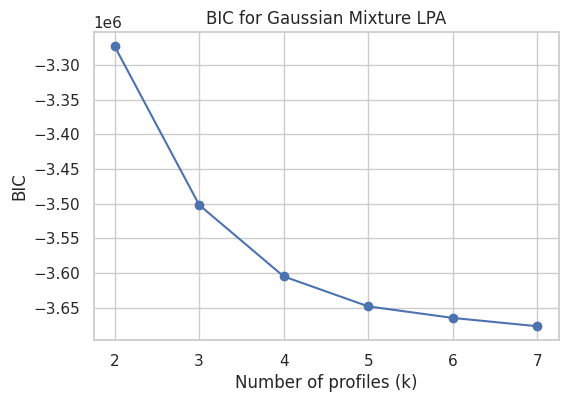

,count
LPA_Profile,
1,22152
2,13663
4,9231
5,7477
0,5121
6,4057
3,3736


In [ ]:
ks = range(2, 8)   # try 2–7 clusters
bic_scores = []

for k in ks:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE
    )
    gmm.fit(probs_all)
    bic = gmm.bic(probs_all)
    bic_scores.append(bic)
    print(f"k={k}, BIC={bic:.2f}")

# Pick best k (lowest BIC)
best_k = ks[np.argmin(bic_scores)]
print("\nBest k according to BIC:", best_k)

plt.figure(figsize=(6,4))
plt.plot(ks, bic_scores, marker="o")
plt.xlabel("Number of profiles (k)")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture LPA")
plt.show()

# Fit final GMM with best_k
gmm_best = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=RANDOM_STATE
)
gmm_best.fit(probs_all)
cluster_labels_lpa = gmm_best.predict(probs_all)   # length = n_samples

df["LPA_Profile"] = cluster_labels_lpa
df["LPA_Profile"].value_counts()


In [ ]:
# 5.1 Build [probs || SHAP] for SHAP subset
prob_blocks_sample = [probs_dict[t][shap_idx] for t in targets]
probs_sample_concat = np.concatenate(prob_blocks_sample, axis=1)  # (shap_sample_size, sum classes)

shap_blocks_sample = [shap_inst[t] for t in targets]  # each (shap_sample_size, n_features)
shap_sample_concat = np.concatenate(shap_blocks_sample, axis=1)   # (shap_sample_size, 3*n_features)

X_expl = np.concatenate([probs_sample_concat, shap_sample_concat], axis=1)
print("Explanatory cluster input shape:", X_expl.shape)

# 5.2 Run Gaussian Mixture on explanatory space
k_expl = best_k   # could reuse LPA k, or choose separately
gmm_expl = GaussianMixture(
    n_components=k_expl,
    covariance_type="full",
    random_state=RANDOM_STATE
)
gmm_expl.fit(X_expl)
expl_clusters = gmm_expl.predict(X_expl)

# Store these clusters only for the SHAP subset
expl_cluster_series = pd.Series(index=shap_idx, data=expl_clusters, name="Expl_Profile")
df["Expl_Profile"] = np.nan
df.loc[shap_idx, "Expl_Profile"] = expl_clusters.astype(int)

df[["LPA_Profile", "Expl_Profile"]].head()


Explanatory cluster input shape: (1000, 51)


,LPA_Profile,Expl_Profile
0,4,NaN
1,2,NaN
2,2,NaN
3,4,NaN
4,1,NaN


In [ ]:
# 6.1 Cluster means for inputs & probs (LPA profiles)
profile_summaries = []

for p in range(best_k):
    mask = (df["LPA_Profile"] == p)
    group = df.loc[mask]
    size = mask.sum()

    feat_mean = group[features].mean()

    # mean calibrated probabilities per target
    prob_means = {}
    for t in targets:
        prob_means[t] = probs_dict[t][mask].mean(axis=0)  # per-class probs

    profile_summaries.append({
        "profile": p,
        "size": size,
        "feature_means": feat_mean,
        "prob_means": prob_means
    })

print(f"\nProfile summaries (LPA) for k={best_k}:")
for ps in profile_summaries:
    print(f"\nProfile {ps['profile']} (n={ps['size']}):")
    print("  Key feature means (top 5 by magnitude):")
    print(ps["feature_means"].abs().sort_values(ascending=False).head())
    print("  Label probability means:")
    for t in targets:
        print(f"   {t}: {ps['prob_means'][t]}")

# 6.2 Decision tree rules to describe LPA profiles
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)
dt.fit(df[features], df["LPA_Profile"])

rules_text = export_text(dt, feature_names=features)
print("\nDecision tree rules describing LPA profiles:\n")
print(rules_text)



Profile summaries (LPA) for k=7:

Profile 0 (n=5121):
  Key feature means (top 5 by magnitude):
coding_years      15.949033
languages_used     6.108573
tools_used         5.281390
org_size           4.383519
tech_count         4.170670
dtype: float64
  Label probability means:
   Frustration: [0.11651972 0.28980922 0.59367106]
   JobSat: [0.19266817 0.3073755  0.49995633]
   JobPerspectiveClass: [0.01946051 0.0889464  0.89159309]

Profile 1 (n=22152):
  Key feature means (top 5 by magnitude):
coding_years      13.824034
languages_used     5.176327
org_size           3.725352
tools_used         3.614707
learning_count     3.164590
dtype: float64
  Label probability means:
   Frustration: [3.49665268e-03 9.95820257e-01 6.83090527e-04]
   JobSat: [8.46118948e-04 8.49731758e-01 1.49422123e-01]
   JobPerspectiveClass: [0.01601714 0.07181763 0.91216522]

Profile 2 (n=13663):
  Key feature means (top 5 by magnitude):
coding_years              15.555295
languages_used             5.427871
too

In [ ]:
pd.DataFrame([
    {
        "profile": ps["profile"],
        "size": ps["size"],
        **ps["feature_means"].to_dict(),
        **{f"{t}_class{i}": v for t, arr in ps["prob_means"].items() for i, v in enumerate(arr)}
    }
    for ps in profile_summaries
]).to_csv("LPA_full_profile_summary_2024.csv", index=False)


In [ ]:
from sklearn.utils import resample

n_boot = 5
ari_scores = []

for b in range(n_boot):
    boot_idx = resample(
        np.arange(n_samples),
        replace=True,
        n_samples=n_samples,
        random_state=RANDOM_STATE + b
    )
    X_boot = probs_all[boot_idx]

    gmm_boot = GaussianMixture(
        n_components=best_k,
        covariance_type="full",
        random_state=RANDOM_STATE + b
    )
    gmm_boot.fit(X_boot)
    labels_boot = gmm_boot.predict(X_boot)

    # Compare to original LPA labels on same indices
    ari = adjusted_rand_score(cluster_labels_lpa[boot_idx], labels_boot)
    ari_scores.append(ari)
    print(f"Bootstrap {b+1}, ARI={ari:.3f}")

print("\nMean ARI across bootstraps:", np.mean(ari_scores))
print("Std of ARI:", np.std(ari_scores))


Bootstrap 1, ARI=0.944
Bootstrap 2, ARI=0.845
Bootstrap 3, ARI=0.616
Bootstrap 4, ARI=0.727
Bootstrap 5, ARI=0.877

Mean ARI across bootstraps: 0.8017816160211634
Std of ARI: 0.11644758595837712


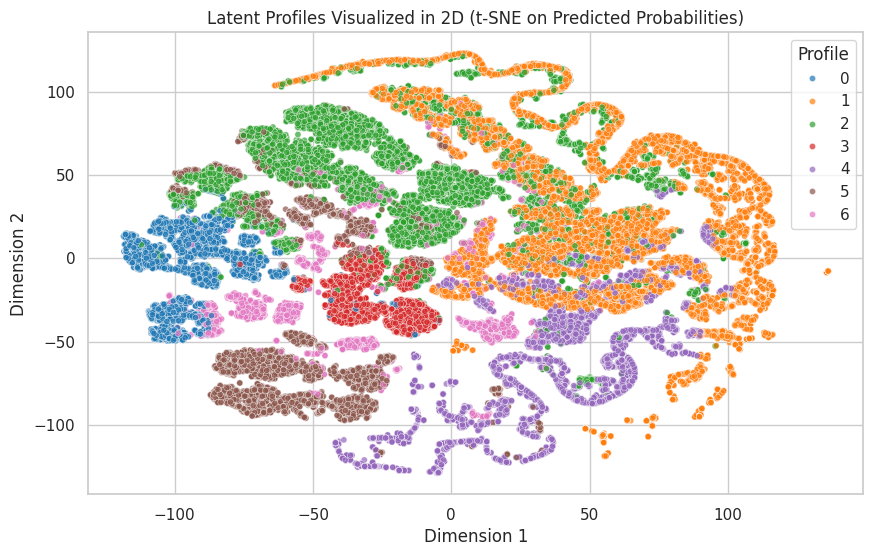

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# probs_all = your probability matrix used for LPA (n_samples × 9)
# cluster_labels_lpa = GMM labels from your LPA

# Reduce to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=40)
probs_2d = tsne.fit_transform(probs_all)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=probs_2d[:, 0],
    y=probs_2d[:, 1],
    hue=cluster_labels_lpa,
    palette="tab10",
    s=20,
    alpha=0.7
)

plt.title("Latent Profiles Visualized in 2D (t-SNE on Predicted Probabilities)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Profile")
plt.show()


/tmp/ipython-input-3411861224.py:35: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])


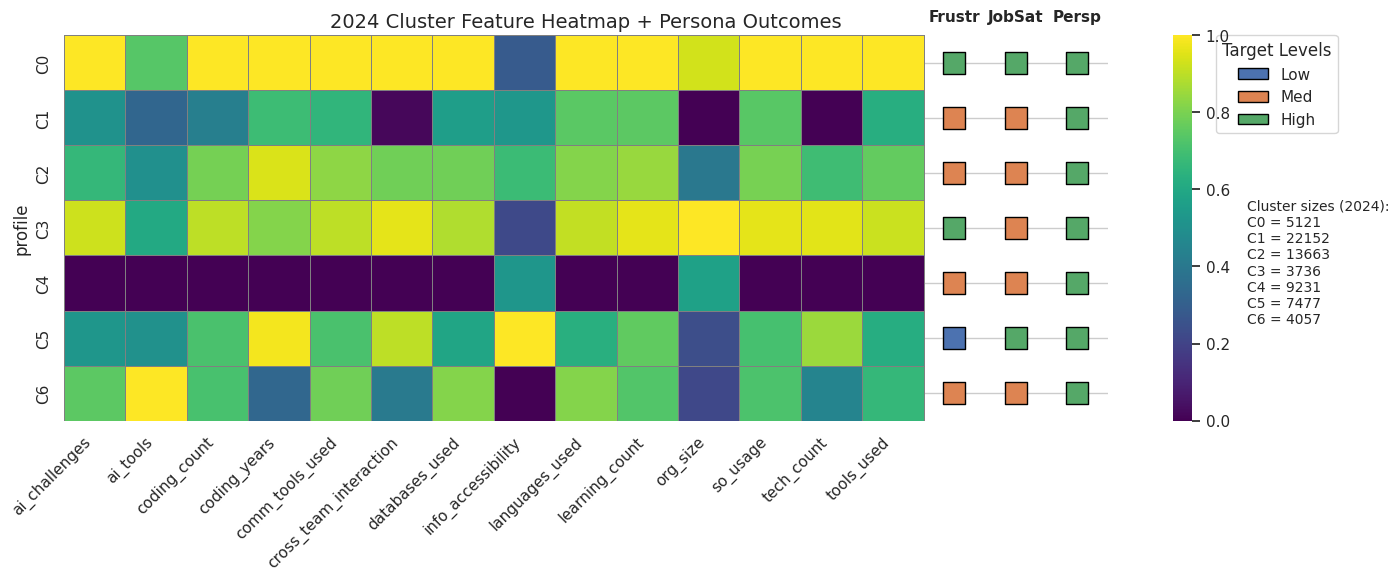

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as Patch

# === Load data ===
df = pd.read_csv("LPA_full_profile_summary_2024.csv")
cluster_col = "profile"

# === Detect continuous features automatically ===
feat_cols = [
    c for c in df.columns
    if c not in ['profile','size']
    and not c.endswith('class0')
    and not c.endswith('class1')
    and not c.endswith('class2')
]

# === Persona target classes ===
targets = {
    'Frustr': ['Frustration_class0','Frustration_class1','Frustration_class2'],
    'JobSat': ['JobSat_class0','JobSat_class1','JobSat_class2'],
    'Persp': ['JobPerspectiveClass_class0','JobPerspectiveClass_class1','JobPerspectiveClass_class2'],
}

level_map = {0:'Low',1:'Med',2:'High'}
level_colors = {'Low':'#4C72B0','Med':'#DD8452','High':'#55A868'}

# === Dominant persona per cluster ===
tmp = df.set_index(cluster_col)[sum(targets.values(), [])]
persona = {}
for t, cols in targets.items():
    persona[t] = tmp[cols].idxmax(axis=1).str[-1].astype(int)
persona_df = pd.DataFrame(persona).applymap(lambda x: level_map[x])

# === Cluster sizes ===
sizes = df.set_index(cluster_col)['size']

# === Normalize features (0-1 absolute scale) ===
feat = df.set_index(cluster_col)[feat_cols]
feat_norm = (feat - feat.min()) / (feat.max() - feat.min())

clusters = sorted(feat_norm.index.tolist())

# === Plot ===
fig, ax = plt.subplots(figsize=(14,6))
sns.set(style="white")

sns.heatmap(
    feat_norm.loc[clusters],
    cmap="viridis",
    linewidths=0.4,
    linecolor="gray",
    cbar=True,
    ax=ax
)

# Extend axis for persona squares
ax.set_xlim(0, len(feat_cols) + 3)

# === Add persona squares ===
for i, c in enumerate(clusters):
    for j, t in enumerate(['Frustr','JobSat','Persp']):
        lev = persona_df.loc[c, t]
        ax.scatter(
            len(feat_cols) + j + 0.5,
            i + 0.5,
            s=250,
            marker='s',
            color=level_colors[lev],
            edgecolor='black'
        )

# === Axis labeling ===
ax.set_xticks(np.arange(len(feat_cols)) + 0.5)
ax.set_xticklabels(feat_cols, rotation=45, ha='right')

ax.set_yticks(np.arange(len(clusters)) + 0.5)
ax.set_yticklabels([f"C{c}" for c in clusters])

# === Persona column headers ===
for j, t in enumerate(['Frustr','JobSat','Persp']):
    ax.text(
        len(feat_cols) + j + 0.5,
        -0.2,
        t,
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# === Persona legend ===
legend_handles = [
    Patch.Patch(facecolor=color, edgecolor='black', label=lev)
    for lev, color in level_colors.items()
]
plt.legend(
    handles=legend_handles,
    title="Target Levels",
    bbox_to_anchor=(1.22, 1),
    borderaxespad=0,
    frameon=True
)

# === Add cluster size legend ===
size_text = "Cluster sizes (2024):\n" + "\n".join(
    [f"C{c} = {sizes[c]}" for c in clusters]
)
plt.gcf().text(
    0.90, 0.65,
    size_text,
    fontsize=10,
    va='top',
    ha='left'
)

plt.title("2024 Cluster Feature Heatmap + Persona Outcomes", fontsize=14)
plt.tight_layout()
plt.show()
